# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _(Krishna lund)_

**Roll Number:** _(023-24-0271)_

**GitHub Repository:** _(link, added before submission)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [3]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")   # update path/filename if different


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
_(The business problem is to understand why customers leave the telecom company and identify which types of customers are more likely to churn.The target variable in this dataset is Churn, because it indicates whether a customer has left the company or stayed.)_

**Answer 2:**
_(Usefull columns-->
1.tenure:  Customer length of stay may be related to their chances of leaving.
2.Contract: Month-to-Month customers have less commitment and may be more likely to churn.
3.TotalCharges: The total amount a customer has paid may be related to their tenure and customer behaviour.
4.Monthly Charges: Higher monthly costs may influence a customer's decision to leave.
5.InternetService: Different internet services may have noticeably different churn rates.

Useless Columns-->
1.customerID: It is only a unique identifier and contains no meaningful customer charachteristics.
2.gender: Gender alone is not expected to strongly explain whether a customer will churn.
)_

**Answer 3:**
_(1.Are customers with month-to-month contacts more likely to churn than customers with one-year or two-year contacts?
2.Are customers with higher monthly charges more likely to churn than customers with lower monthly charges.)_

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [1]:
# Task 4 — dataset shape, column names, data types
import pandas as pd
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Number of customers:", df.shape[0])

print("Number of columns:", df.shape[1])

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns
print("\nNumerical features:")
print(numerical_features.tolist())

categorical_features = df.select_dtypes(include=["str"]).columns
print("\nCategorical features:")
print(categorical_features.tolist())



Number of customers: 7043
Number of columns: 21

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [ ]:
# Task 5 — identify identifier columns / wrong data types
#Answer: 
#Identifier Column: customerId 
#Wrong data type: TotalCharges because it's actual meaning doesnot match the data type pandas assigned. Pandas assigned it a str/object datatype, where as it's correct datatype should be float.

df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [ ]:
# Task 6 — unique values in 3 categorical columns
#Answer:
#I selected PaymentMethod, Contract, and InternetService.Their categories are consistent and expected, and I did not find any unexpected or inconsistent categories.Some other service-related columns contain
#values such as No phone service and No internet service, but these are valid categories because they indicate that the underlying service is unavailable rather than representing inconsistent data.

print(df["PaymentMethod"].unique())
print(df["Contract"].unique())
print(df["InternetService"].unique())

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str


**Observations (Part 2):**
_(The dataset contains 7,043 customers and 21 columns. The numerical features are SeniorCitizen, tenure, and MonthlyCharges, while most of the remaining columns are categorical. I identified customerID as an identifier and TotalCharges as having an incorrect string data type even though it represents numerical charges. The selected categorical columns (PaymentMethod, Contract, and InternetService) contain expected categories, and values such as No phone service and No internet service are valid categories rather than inconsistencies.)_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [2]:
# Task 7 — missing values: count and percentage per column
print("Null values in each column:")
print(df.isnull().sum())

# Calculate missing percentage for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing percentage in each column:")
print(missing_percentage.round(2))

blank_totalcharges = df["TotalCharges"].eq(" ").sum()

# Calculate percentage of blank TotalCharges
blank_percentage = (blank_totalcharges / len(df)) * 100

print("\nBlank values in TotalCharges:", blank_totalcharges)
print(f"Percentage of blank TotalCharges: {blank_percentage:.2f}%")

Null values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Missing percentage in each column:
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
Total

In [ ]:
# Task 8 — duplicate rows vs duplicate IDs
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())


Duplicate rows: 0
Duplicate customer IDs: 0


In [12]:
# Task 9 — investigate a suspicious / invalid value
print(df.dtypes)

# Check for blank values in TotalCharges
blank_values = df["TotalCharges"].eq(" ").sum()

print("\nBlank values in TotalCharges:", blank_values)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Blank values in TotalCharges: 11


**Answer 7 (which missing-value problems need action, and why):**
_( df.isnull().sum() shows that there are no null values in the dataset.However,I found that TotalCharges contains 11 blank values because its data type is str/object
instead of float.These 11 blank values are about 0.16% of the dataset, so they should be noted as a missing value issue, but they are not a major problem because
they represent a very small portion of the data.)_

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_(There are no duplicate rows and no duplicate customer IDs in the dataset. These are different issues: duplicate rows mean the entire record is repeated,
while duplicate customer IDs means the same customer identifier appears more than once, even if the other information is different.)_

**Answer 9 (suspicious value found and how):**
_(I found TotalCharges to be a suspicious column by checking df.dtypes. Pandas identified it as a string/object data type even though it repeats numerical charges.
I then checked for blank values using df["TotalCharges"].eq(" ").sum() and found 11 blank values, which shows that the column contains invalid/missing
entries that need to be investigated.)_

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| _TotalCharges has an incorrect data type(string/object even though it represents numerical charges.)_ | _Convert it to a numerical type later._ | _pd.to_numeric(df["TotalCharges"],errors="coerce")_ | _TotalCharges represents money, so it should be numerical for calculations and analysis._ |
| _TotalCharges contains 11 blank string values._ | _Convert them to numeric and fill the resulting missing values with 0._ | _df["TotalCharges"].eq("").sum()_ | _The 11 blank values belong to customers with tenure = 0, so treating their total charges as 0 is reasonable because they have not accumulated any charges._ |
| _customerID is an identifier rather than a useful feature._ | _keep it for identification,but exclude it from prediction._ | _df.drop("customerID",axis=1) when preparing ML features_ | _The ID identifies customers but doesn't provide meaningful information about their churn behaviour._ |

In [3]:
# Task 11 — apply your cleaning decisions here
# Create a copy for cleaning
cleaned_df = df.copy()

# Convert TotalCharges from string/object to numeric
cleaned_df["TotalCharges"] = pd.to_numeric(
    cleaned_df["TotalCharges"],
    errors="coerce"
)

print("\nTotalCharges data type:")
print(cleaned_df["TotalCharges"].dtype)

print("\nMissing TotalCharges:")
print(cleaned_df["TotalCharges"].isnull().sum())


TotalCharges data type:
float64

Missing TotalCharges:
11


In [6]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)

# 1. Check missing values
print("Missing values:")
print(cleaned_df.isnull().sum())

# 2. Check duplicate rows
print("\nDuplicate rows:")
print(cleaned_df.duplicated().sum())

# 3. Check duplicate customer IDs
print("\nDuplicate customer IDs:")
print(cleaned_df["customerID"].duplicated().sum())

# 4. Check data types
print("\nData types:")
print(cleaned_df.dtypes)

Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Duplicate rows:
0

Duplicate customer IDs:
0

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract 

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

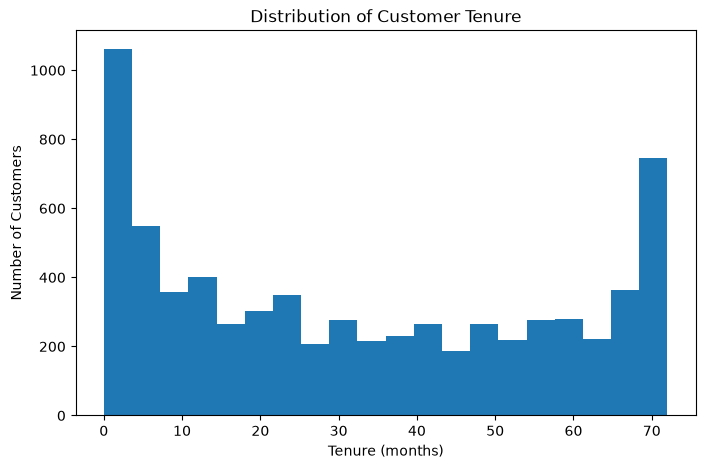

In [7]:
# Task 12 — numerical feature 1: distribution plot
# numerical feature1: tenure
plt.figure(figsize=(8, 5))
plt.hist(cleaned_df["tenure"], bins=20)
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")
plt.show()

**Observation:** _(Most customers are distributed across different tenure periods, with noticeable numbers of both newer and long-term customers.)_

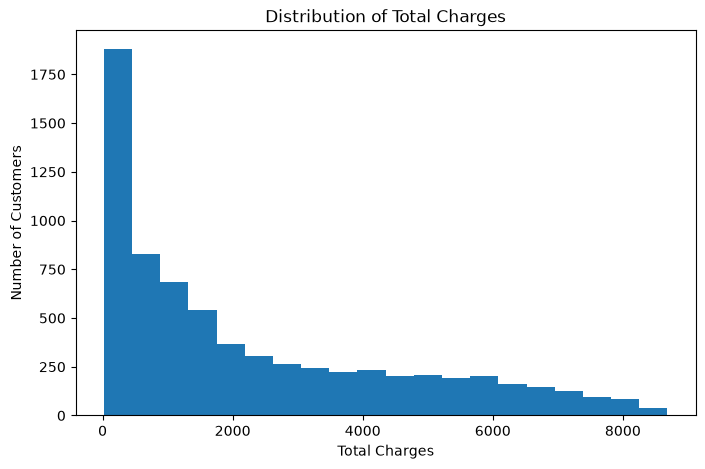

In [8]:
# Task 12 — numerical feature 2: distribution plot
# numerical feature2: TotalCharges
plt.figure(figsize=(8, 5))
plt.hist(cleaned_df["TotalCharges"].dropna(), bins=20)
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Total Charges")
plt.show()

**Observation:** _(Most customers have relatively lower total charges, while fewer customers have very high total charges. This makes sense because customers with longer tenure generally accumulate higher total charges.)_

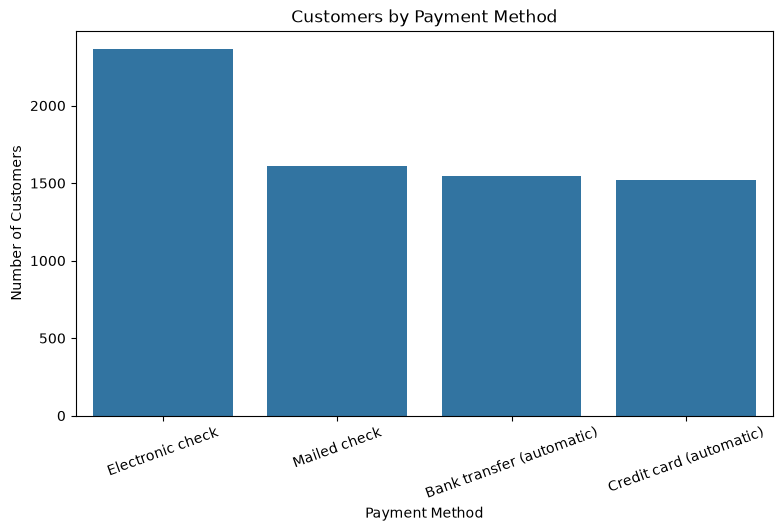

In [9]:
# Task 12 — categorical feature 1: distribution plot
# categorical feature 1 : PaymentMethod
plt.figure(figsize=(9, 5))
sns.countplot(data=cleaned_df, x="PaymentMethod")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.title("Customers by Payment Method")
plt.xticks(rotation=20)
plt.show()

**Observation:** _(Electronic check is one of the commonly used payment methods, while the automatic payment methods also have a substantial number of customers.)_

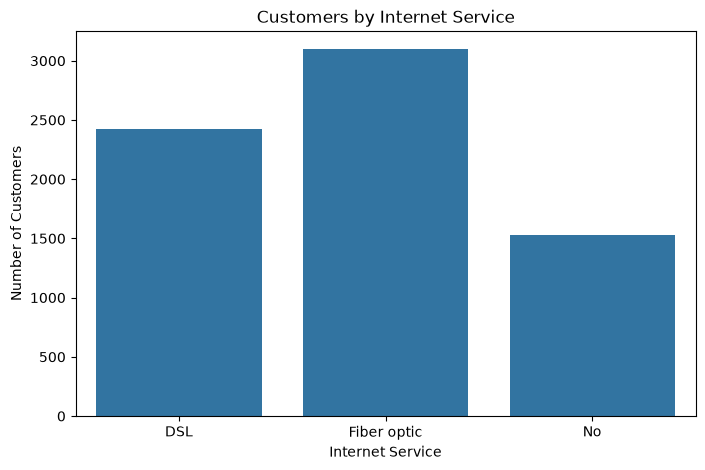

In [10]:
# Task 12 — categorical feature 2: distribution plot
# categorical feature 2: InternetService
plt.figure(figsize=(8, 5))
sns.countplot(data=cleaned_df, x="InternetService")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Customers by Internet Service")
plt.show()

**Observation:** _(DSL and Fiber optic services are used by a large portion of customers, while some customers have no internet service.)_

**Answer 13 (outliers / skew and possible explanation):**
_(TotalCharges is right-skewed.Many customers have relatively low TotalCharges while a smaller number of long-term customers have very high total charges. This creates a right-skewed distribution.
  MonthlyCharges also shows variation because customers subscribe to differnet combinations of services, while tenure does not show major extreme outliers because it has a natural limit of 72 months.)_  

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [7]:
# Task 14 — churn counts and percentages
churn_count = cleaned_df["Churn"].value_counts()

print("Churn counts:")
print(churn_count)

churn_percentage = cleaned_df["Churn"].value_counts(normalize=True) * 100

print("\nChurn percentages:")
print(churn_percentage.round(2))

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
_(There are 5174 customers who didnot churn(73.46%) and 1869 customers who churned (26.54%). Therefore, the target variable Churn is imbalanced because the non-churned customers are much more numerous than the churned customers.)_

**Answer 15 (why imbalance might matter later):**
_(Class imbalance matters because the model may learn more from the majority class(No Churn) and perform well on it while performing poorly on the minority class (Churn). This is important because correctly identifying customers who are likely to churn is usually the main goal of a churn prediction model.)_

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [8]:
# Task 16 — categorical feature 1 vs Churn
# Contract vs Churn
contract_churn = pd.crosstab(
    cleaned_df["Contract"],
    cleaned_df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


**Observation:** _Customers with month-to-month contracts have a much higher churn rate than customers with one-year or two-year contracts._
**Evidence:** _The Contract vs Churn table shows a larger percentage of Yes under Churn for month-to-month customers._
**Possible Explanation:** _Month-to-month customers have less contractual commitment, so they may find it easier to leave the company compared with customers committed to one or two-year contracts._

In [9]:
# Task 16 — categorical feature 2 vs Churn
# InternetService vs Churn
internet_churn = pd.crosstab(
    cleaned_df["InternetService"],
    cleaned_df["Churn"],
    normalize="index"
) * 100

print(internet_churn.round(2))

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


**Observation:** _Customers using Fiber optic internet appear to have a higher churn rate than customers using DSL or having no internet service._
**Evidence:** _The percentage of Yes in the Churn column is higher for the Fiber optic category._
**Possible Explanation:** _Fiber optic customers may have higher charges or different service experiences, which could contribute to a greater chance of leaving._

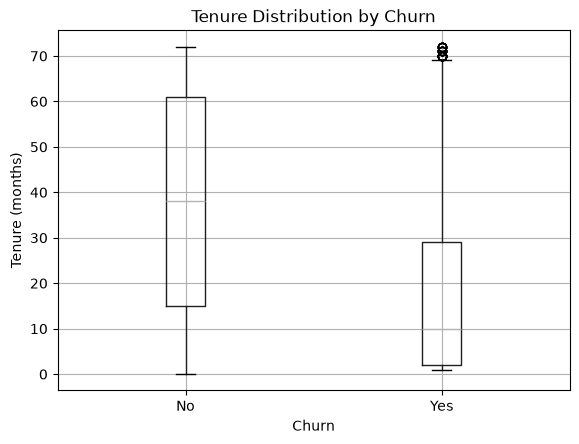

In [11]:
# Task 17 — numerical feature 1 vs Churn
# tenure vs Churn
df.boxplot(column='tenure',by='Churn')
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.show()

**Observation:** _Churned customers generally have lower tenure._
**Evidence:** _The median tenure for Churn = Yes is lower than for Churn = No._
**Possible Explanation:** _Newer customers may have less loyalty or commitment to the company._

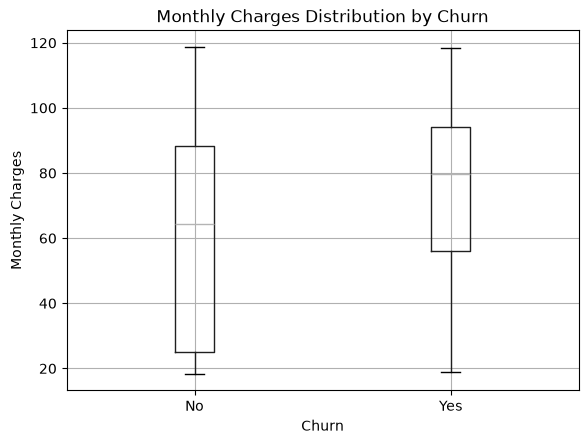

In [ ]:
# Task 17 — numerical feature 2 vs Churn
# MonthlyCharges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn')
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges Distribution by Churn")
plt.suptitle("")
plt.show()

**Observation:** _Churned customers generally have higher monthly charges._
**Evidence:** _The median MonthlyCharges for Churn = Yes is higher than for Churn = No._
**Possible Explanation:** _Higher monthly costs may make customers more likely to leave._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                 tenure  TotalCharges  MonthlyCharges
tenure          1.00000      0.825880        0.247900
TotalCharges    0.82588      1.000000        0.651065
MonthlyCharges  0.24790      0.651065        1.000000


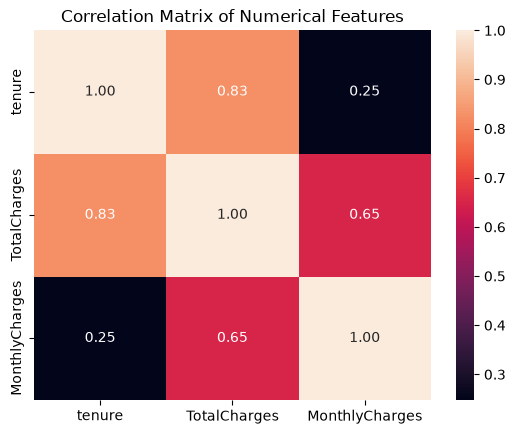

In [8]:
# Task 18 — correlation matrix and heatmap

numerical_df = cleaned_df[["tenure", "TotalCharges", "MonthlyCharges"]]
correlation_matrix = numerical_df.corr()
print(correlation_matrix)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

**Answer 18 (most correlated pairs):**
_(The strongest correlation appears between tenure and TotalCharges. This makes sense because customers who stay longer generally accumulate higher total charges. MonthlyCharges also has a positive relationship with TotalCharges because higher monthly charges can lead to higher total charges over time.)_

**Answer 19 (correlation vs. causation; potential problems):**
_(Correlation does not imply causation because the correlation matrix only shows that two features are related, it does not prove that one feature causes the other. tenure and TotalCharges are highly correlated because customers who stay longer generally accumulate more total charges and this high correlation could cause multicollinearity (when two or more predictor features in a model are highly correlated and provide similar information) in models such as linear regression, making the model coefficients harder to interpret.)_

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_(The main identifier column is customerID because it uniquely identifies each customer but does not provide useful information about their churn behaviour.Churn is the target variable and should not be used as a predictor because it represents the outcome we are trying to predict.)_

**Answer 21 (what would go wrong):**
_(If an identifier or a column that contains information known only after churn were included as a model input, the model could learn information that would not actually be available when predicting a customer's future churn. This could cause data leakage, making the model appear more accurate during training/testing but perform poorly on real future customers.)_

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | It uniquely identifies customers but provides no meaningful information for predicting churn |
| tenure | Numerical | Feature | Keep | It represents how long the customer has stayed and is strongly related to churn behaviour |
| Contract | Categorical | Feature | Keep | Contract type is strongly associated with churn,month-to-month customers tend to churn more |
| Churn | Categorical | Target | Keep | This is the outcome we want the model to predict |
| gender | Categorical | Feature | Keep | It describes the customer and can be investigated as a possible predictor of churn |
| SeniorCitizen | Numerical | Feature | Keep | It indicates whether the customer is a senior citizen and may be related to churn behavior |
| Partner | Categorical | Feature | Keep | Having a partner may be associated with customer stability and churn behavior |
| Dependents | Categorical | Feature | Keep | Having dependents may influence customer needs and likelihood of leaving |
| PhoneService | Categorical | Feature | Keep | It describes whether the customer has phone service and may provide useful information about churn |
| MultipleLines | Categorical | Feature | Keep | It describes the customer's phone-line service and may be related to churn |
| InternetService | Categorical | Feature | Keep | Different internet services may have different churn rates |
| OnlineSecurity | Categorical | Feature | Keep | Use of online security services may be associated with customer retention |
| OnlineBackup | Categorical | Feature | Keep | It describes an additional service that may help explain churn behaviour |
| DeviceProtection | Categorical | Feature | Keep | It describes whether the customer uses device protection and may relate to churn |
| TechSupport | Categorical | Feature | Keep | Technical support usage may be associated with customer satisfaction and churn |
| StreamingTV | Categorical | Feature | Keep | It describes the customer's service usage and may help predict churn |
| StreamingMovies | Categorical | Feature | Keep | It describes the customer's service usage and may provide information about churn |
| PaperlessBilling | Categorical | Feature | Keep | It describes the customer's billing preference and may have an association with churn |
| PaymentMethod | Categorical | Feature | Keep | Different payment methods show different churn patterns |
| MonthlyCharges | Numerical | Feature | Keep | Monthly cost varies between customers and may be associated with churn  |
| TotalCharges | Numerical | Feature | Keep | It represents the total amount charged and may provide useful information about customer behaviour |

_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [9]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# 1. Convert TotalCharges to numeric
clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)

# 2. Handle missing TotalCharges
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(0)

# 3. Remove customerID because it is only an identifier
clean_df = clean_df.drop(columns=["customerID"])

# 4. Check duplicates after removing the identifier
print("Duplicates before removal:", clean_df.duplicated().sum())

# 5. Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# 6. Save cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)

print("Cleaned dataset saved successfully!")


Duplicates before removal: 22
Cleaned dataset saved successfully!


In [10]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print("DataFrame Information:")
clean_df.info()

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nDuplicate rows:")
print(clean_df.duplicated().sum()) 

DataFrame Information:
<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   s

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1 - Churn is imbalanced**
- Observation: _Most customers did not churn, while a samller portion of customers churned._
- Evidence: _5,174 customers (73.46%) did not churn, while 1,869 (26.54%) churned._
- Interpretation: _Churn is an imbalanced target, so predicting the minority class (customers who churn) will be particularly important in a future model._

**Finding 2 - Contract type is strongly related to churn**
- Observation: _Month-to-month customers have a much higher churn rate than customers with one-year or two-year contracts._
- Evidence: _The Contract VS Churn analysis showed more Churn = Yes among month-to-month customers._
- Interpretation: _Customers with shorter contracts may have less commitment to the company._

**Finding 3 - Tenure is related to churn**
- Observation: _Churned customers generally have lower tenure than customers who stayed._
- Evidence: _The box plot of tenure against Churn showed that the distribution and median tenure of churned customers were lower._
- Interpretation: _Newer customers appear more likely to churn, while customers who have stayed longer tend to be more retained._

**Finding 4 - Monthly charges are related to churn**
- Observation: _Customers who churn generally have higher monthly charges than customers who do noy churn._
- Evidence: _The MonthlyCharges vs Churn box plot showed a higher distribution or median for the churned group._
- Interpretation: _Higher monthly charges may be associated with a greater likelihood of churn,although this does not prove that higher charges cause customers to leave._

**Finding 5 - Total charges and tenure are highly correlated**
- Observation: _tenure and TotalCharges have a strong positive correlation._
- Evidence: _The correlation matrix showed that these two numerical features had the strongest correlation._
- Interpretation: _This makes sense because customers who stay longer generally accumulate more total charges.This relationship should be considered when building a future model becuause highly correlated predictors can create multicollinearity in models such as logistic regression._

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   _(TotalCharges was stored as a string and had 11 blank values that were not detected by isnull())._
2. What was the most interesting pattern you discovered?
   _(Month-to-month customers had a much higher churn rate than customers with longer contracts.)_
3. Which feature seems most useful for predicting churn?
   _(Contract seems highly useful because its categories show clear differences in churn.)_
4. Which feature should probably not be used, and why?
   _(customerID should not be used because it is only an identifier and has no meaningful predictive information.)_
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   _(Encode categorical features , handle missing values, and scale numerical features if required by the Ml algorithm.)_
6. What would you do next if you had another 3 hours?
   _(I would investigate more features against churn and then build and compare a few classification models.)_

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook